# __Histograms and binary images__
Jesús David Petro Ramos - T00065696

Link del repo donde he estado realizando la actividad: [Repo](https://github.com/JesusPetro/Vision-Artificial-2P2025/blob/main/semana%207/t00065696_work7.ipynb)


In [148]:
import cv2
import numpy as np
from skimage import io
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# define the filepath
path = './img/fruit.jpg'
pathv2 = './img/screw-img.jpg'

### __Plot img__

Se carga una imagen y se visualiza junto a su versión procesada. La imagen procesada primero se convierte a escala de grises y luego se le aplica un desenfoque Gaussiano. Finalmente, ambas se muestran en una figura comparativa para observar el efecto del filtro.  


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_grayScale(img: np.ndarray, ax=None) -> None:
    """
    Display a grayscale image using matplotlib.

    Parameters
    ----------
    img : np.ndarray
        Image to be displayed in grayscale. Should be a 2D NumPy array.
    ax : matplotlib.axes.Axes, optional
        Axis object where the image will be drawn. If None, a new figure
        and axis will be created. Default is None.

    Returns
    -------
    None
        This function does not return anything. It renders the image
        on the provided or newly created axis.
    """
    if ax is None:
        _, ax = plt.subplots()
    ax.imshow(img, cmap="gray")
    ax.axis("off")


def plot_subplots(img: np.ndarray, blurred: np.ndarray, title: str = "") -> None:
    """
    Display the original and blurred images side by side.

    Parameters
    ----------
    img : np.ndarray
        Original image. Can be grayscale or RGB (2D or 3D NumPy array).
    blurred : np.ndarray
        Blurred image to be displayed in grayscale. Should be a 2D NumPy array.
    title : str, optional
        Text to append to the titles of the subplots. Default is an empty string.

    Returns
    -------
    None
        This function does not return anything. It creates a matplotlib
        figure with two subplots and displays them.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))

    ax1.set_title(f"Original img - {title}")
    ax1.imshow(img)
    ax1.axis("off")

    ax2.set_title(f"Blurred img - {title}")
    plot_grayScale(blurred, ax2)

    plt.tight_layout()
    plt.show()


img-fruit.shape = (360, 539, 3)


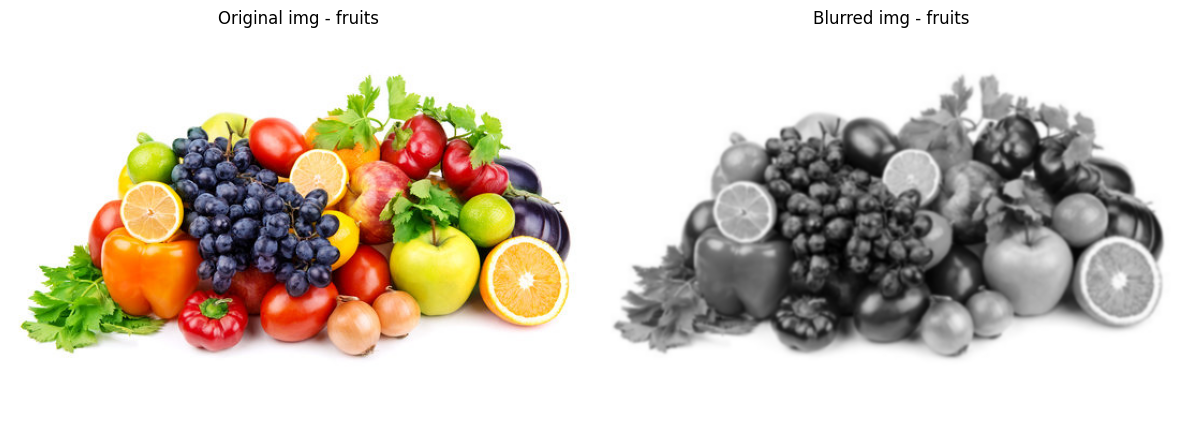

---

img-tool.shape = (414, 735, 3)


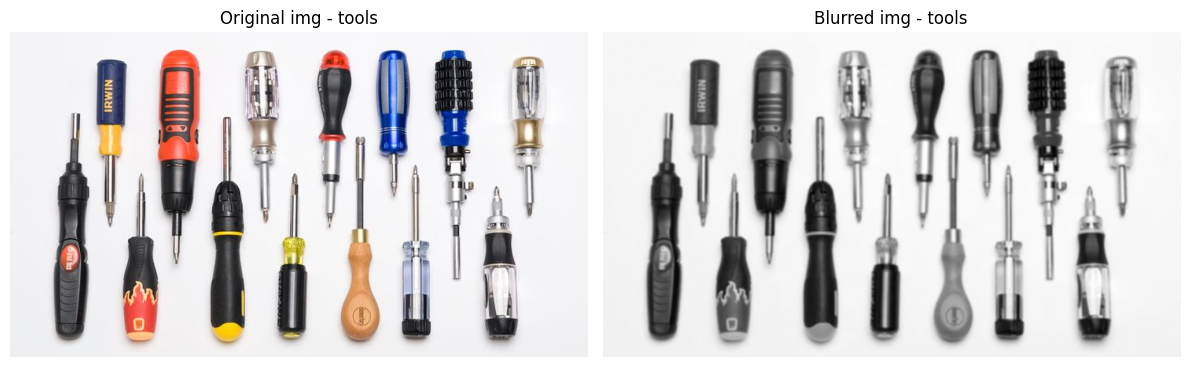

In [ ]:
"""
Este script carga dos imágenes desde rutas dadas, las convierte a escala de grises
y les aplica un filtro de desenfoque Gaussiano.  

Posteriormente, muestra las imágenes originales junto a sus versiones desenfocadas
en subplots para facilitar la comparación visual.

Flujo general:
1. Cargar imágenes desde archivos.
2. Convertir cada imagen a escala de grises.
3. Aplicar un desenfoque Gaussiano (filtro 5x5).
4. Mostrar:
   - Imagen original (color)
   - Imagen desenfocada (grises)
"""



imgv1 = io.imread(path)
imgv2 = io.imread(pathv2)


img_grayv1 = cv2.cvtColor(imgv1, cv2.COLOR_BGR2GRAY)
blurredv1 = cv2.GaussianBlur(img_grayv1, (5,5), 0)


img_grayv2 = cv2.cvtColor(imgv2, cv2.COLOR_BGR2GRAY)
blurredv2 = cv2.GaussianBlur(img_grayv2, (5,5), 0)

# fruit - images
print(f'img-fruit.shape = {imgv1.shape}')
plot_subplots(imgv1, blurredv1, 'fruits')

display(Markdown('---'))

# tools - images
print(f'img-tool.shape = {imgv2.shape}')
plot_subplots(imgv2, blurredv2, 'tools')




Se genera el histograma de la imagen desenfocada en escala de grises para visualizar la distribución de intensidades de píxeles.  


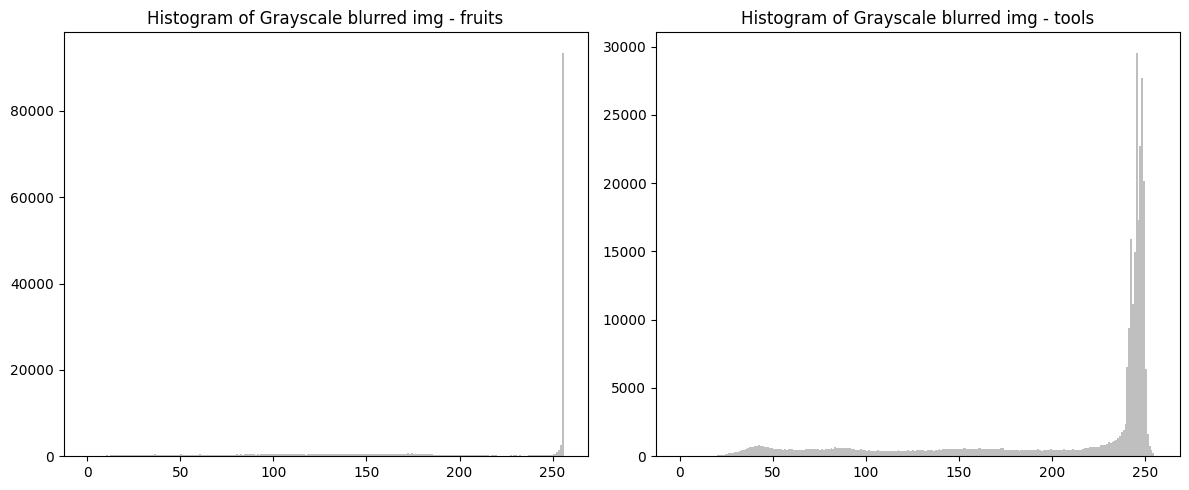

In [ ]:
"""
Este bloque genera y muestra los histogramas de intensidad (niveles de gris) 
de las imágenes desenfocadas.  

Flujo general:
1. Calcular los valores de intensidad en escala de grises de cada imagen.
2. Dibujar el histograma de la imagen de frutas.
3. Dibujar el histograma de la imagen de herramientas.
4. Mostrar ambos histogramas en una figura con dos subplots para su comparación.
"""


# hist_values, bin_edges = np.histogram(blurred.ravel(), bins = 256, range = [0, 256])
# plt.plot(bin_edges[:-1], hist_values, color = 'gray')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histograma frutas
ax1.set_title('Histogram of Grayscale blurred img - fruits')
ax1.hist(blurredv1.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.5)

# Histograma herramientas
ax2.set_title('Histogram of Grayscale blurred img - tools')
ax2.hist(blurredv2.ravel(), bins=256, range=[0, 256], color='gray', alpha=0.5)

plt.tight_layout()
plt.show()


### __Tresholding__

Se aplica un umbral binario para separar los objetos del fondo en blanco y negro. También se muestra la versión inversa, donde los colores se invierten (objetos en blanco y fondo en negro).  


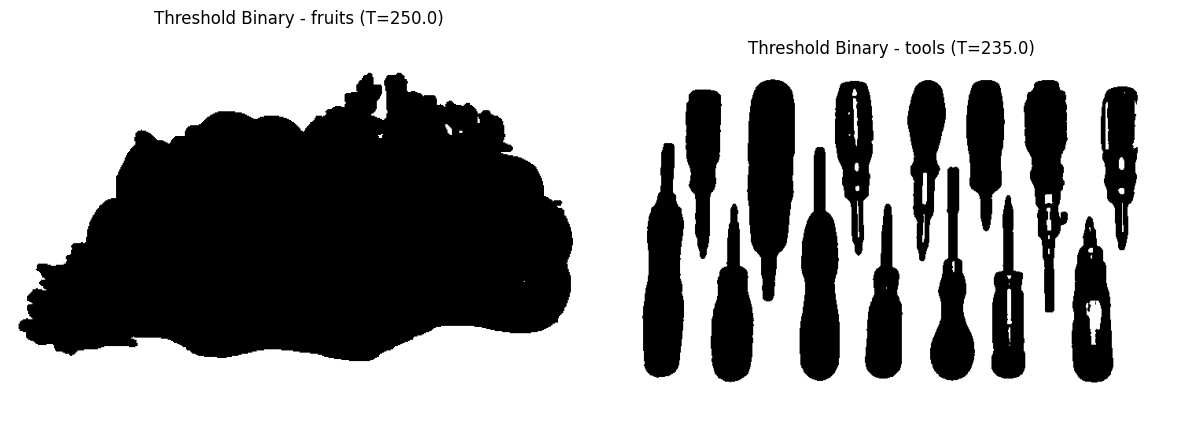

In [ ]:
"""
Este bloque aplica umbralización binaria a las imágenes desenfocadas 
para resaltar las zonas más brillantes.  

Flujo general:
1. Definir un valor de umbral (T) para cada imagen.
2. Convertir los píxeles mayores o iguales a T en blanco (255) y los demás en negro (0).
3. Mostrar la imagen resultante de frutas y herramientas en subplots.
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Threshold Binary (fruits)
T1, threshImg1 = cv2.threshold(blurredv1, 250, 255, cv2.THRESH_BINARY)
ax1.set_title(f'Threshold Binary - fruits (T={T1})')
ax1.imshow(threshImg1, cmap='gray')
ax1.axis('off')

# Threshold Binary (tools)
T2, threshImg2 = cv2.threshold(blurredv2, 235, 255, cv2.THRESH_BINARY)
ax2.set_title(f'Threshold Binary - tools (T={T2})')
ax2.imshow(threshImg2, cmap='gray')
ax2.axis('off')

plt.tight_layout()
plt.show()


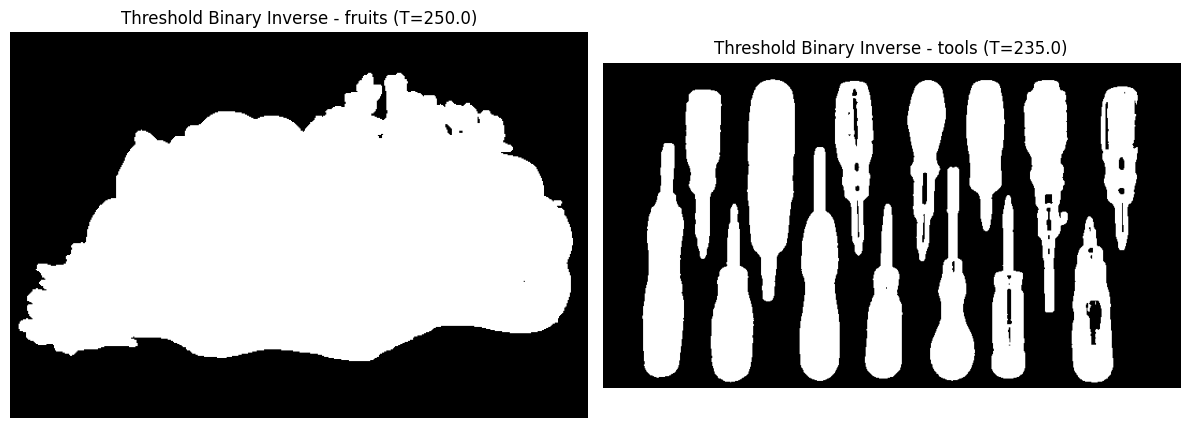

In [ ]:
"""
Este bloque aplica umbralización binaria inversa a las imágenes desenfocadas
para resaltar las zonas oscuras.  

Flujo general:
1. Definir un valor de umbral (T) para cada imagen.
2. Convertir los píxeles menores a T en blanco (255) y los mayores o iguales en negro (0).
3. Mostrar la imagen resultante de frutas y herramientas en subplots para su comparación.
"""

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Threshold Binary Inverse (fruits)
T1, threshInv1 = cv2.threshold(blurredv1, 250, 255, cv2.THRESH_BINARY_INV)
ax1.set_title(f'Threshold Binary Inverse - fruits (T={T1})')
ax1.imshow(threshInv1, cmap='gray')
ax1.axis('off')

# Threshold Binary Inverse (tools)
T2, threshInv2 = cv2.threshold(blurredv2, 235, 255, cv2.THRESH_BINARY_INV)
ax2.set_title(f'Threshold Binary Inverse - tools (T={T2})')
ax2.imshow(threshInv2, cmap='gray')
ax2.axis('off')

plt.tight_layout()
plt.show()


Fruits


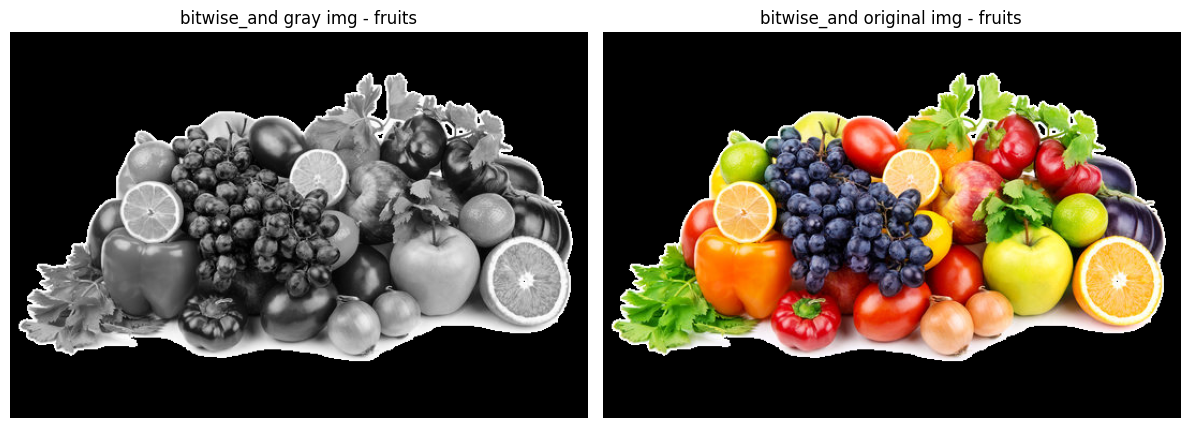

---

Tools


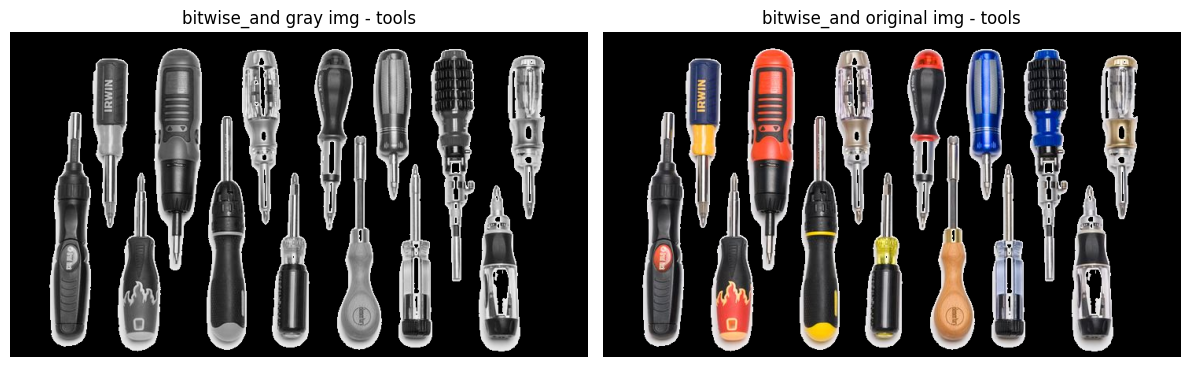

In [ ]:
"""
Este bloque aplica la operación bitwise AND usando las máscaras obtenidas 
por umbralización inversa, con el fin de resaltar regiones específicas de las imágenes.  

Flujo general:
1. Tomar la máscara binaria inversa (threshInv) de cada imagen.
2. Aplicar bitwise AND sobre:
   - La versión en escala de grises.
   - La imagen original en color.
3. Mostrar los resultados en subplots para frutas y herramientas.
"""

print("Fruits")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))

ax1.set_title('bitwise_and gray img - fruits')
plot_grayScale(cv2.bitwise_and(img_grayv1, img_grayv1, mask=threshInv1), ax1)

ax2.set_title('bitwise_and original img - fruits')
plot_grayScale(cv2.bitwise_and(imgv1, imgv1, mask=threshInv1), ax2)

plt.tight_layout()
plt.show()

display(Markdown('---'))

print("Tools")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 10))

ax1.set_title('bitwise_and gray img - tools')
plot_grayScale(cv2.bitwise_and(img_grayv2, img_grayv2, mask=threshInv2), ax1)

ax2.set_title('bitwise_and original img - tools')
plot_grayScale(cv2.bitwise_and(imgv2, imgv2, mask=threshInv2), ax2)

plt.tight_layout()
plt.show()
